In [250]:
import pandas as pd
import datetime 
import matplotlib.pyplot as plt 


def convert_to_hours(delta):
    total_seconds = delta.total_seconds()
    minutes = str(int((total_seconds % 3600) // 60)).zfill(2)

    return int(minutes)


df = pd.read_csv("/Users/the_alive/ALL_PYTHON_PROJECTS/for_jupiter_notebook/Divvy_Trips_2019_Q2.csv")
df = df[df["05 - Member Details Member Birthday Year"] >= 1934]
df = df.drop_duplicates(subset="01 - Rental Details Rental ID")
df

,01 - Rental Details Rental ID,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,01 - Rental Details Bike ID,01 - Rental Details Duration In Seconds Uncapped,03 - Rental Start Station ID,03 - Rental Start Station Name,02 - Rental End Station ID,02 - Rental End Station Name,User Type,Member Gender,05 - Member Details Member Birthday Year
0,22178529,2019-04-01 00:02:22,2019-04-01 00:09:48,6251,446.0,81,Daley Center Plaza,56,Desplaines St & Kinzie St,Subscriber,Male,1975.0
1,22178530,2019-04-01 00:03:02,2019-04-01 00:20:30,6226,"1,048.0",317,Wood St & Taylor St,59,Wabash Ave & Roosevelt Rd,Subscriber,Female,1984.0
2,22178531,2019-04-01 00:11:07,2019-04-01 00:15:19,5649,252.0,283,LaSalle St & Jackson Blvd,174,Canal St & Madison St,Subscriber,Male,1990.0
3,22178532,2019-04-01 00:13:01,2019-04-01 00:18:58,4151,357.0,26,McClurg Ct & Illinois St,133,Kingsbury St & Kinzie St,Subscriber,Male,1993.0
4,22178533,2019-04-01 00:19:26,2019-04-01 00:36:13,3270,"1,007.0",202,Halsted St & 18th St,129,Blue Island Ave & 18th St,Subscriber,Male,1992.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1108156,23479381,2019-06-30 23:57:54,2019-07-01 00:10:47,1044,773.0,215,Damen Ave & Madison St,69,Damen Ave & Pierce Ave,Subscriber,Male,1962.0
1108159,23479384,2019-06-30 23:58:04,2019-07-01 00:14:17,6301,973.0,199,Wabash Ave & Grand Ave,338,Calumet Ave & 18th St,Subscriber,Male,1980.0
1108160,23479385,2019-06-30 23:58:20,2019-07-01 00:25:51,4472,"1,651.0",319,Greenview Ave & Diversey Pkwy,337,Clark St & Chicago Ave,Subscriber,Female,1991.0
1108161,23479386,2019-06-30 23:58:52,2019-07-01 00:11:24,5021,752.0,226,Racine Ave & Belmont Ave,300,Broadway & Barry Ave,Subscriber,Male,1992.0


In [214]:
cnt_per_station_df = df[['01 - Rental Details Rental ID', '03 - Rental Start Station ID', '02 - Rental End Station ID']]
cnt_per_station_df

,01 - Rental Details Rental ID,03 - Rental Start Station ID,02 - Rental End Station ID
0,22178529,81,56
1,22178530,317,59
2,22178531,283,174
3,22178532,26,133
4,22178533,202,129
...,...,...,...
1108156,23479381,215,69
1108159,23479384,199,338
1108160,23479385,319,337
1108161,23479386,226,300


In [215]:
cnt_per_station_df['03 - Rental Start Station ID'].unique(), cnt_per_station_df['02 - Rental End Station ID'].unique()
cnt_per_station_df.groupby(by='03 - Rental Start Station ID')['01 - Rental Details Rental ID'].count().reset_index().sort_values(by=['01 - Rental Details Rental ID'])

,03 - Rental Start Station ID,01 - Rental Details Rental ID
528,568,1
529,569,2
538,578,2
524,564,2
595,652,2
...,...,...
264,287,9625
176,195,10165
69,77,13049
79,91,13237


<BarContainer object of 608 artists>

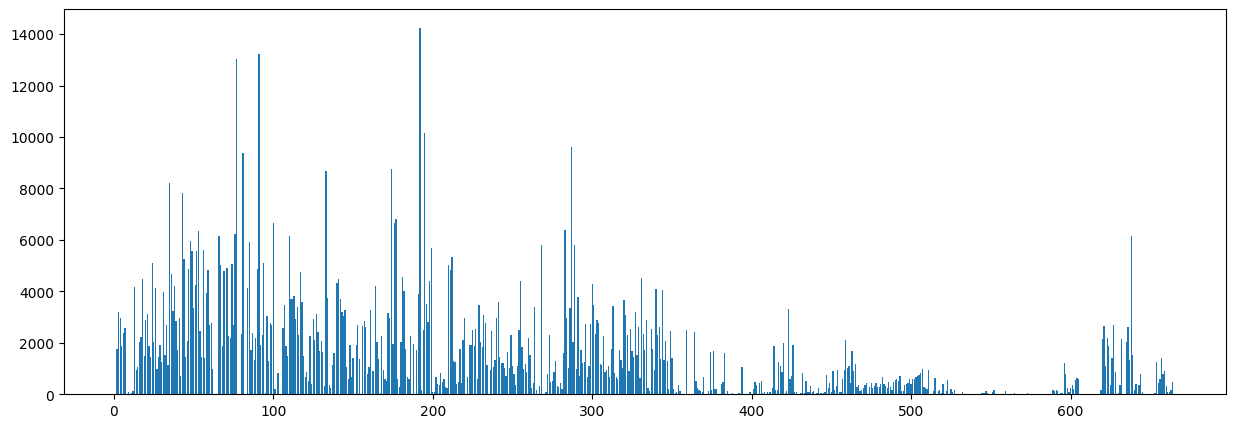

In [216]:
plt.figure(figsize=(15, 5))
test_df = cnt_per_station_df.groupby(by='03 - Rental Start Station ID')['01 - Rental Details Rental ID'].count().reset_index()
plt.bar(test_df['03 - Rental Start Station ID'], test_df['01 - Rental Details Rental ID'])

<BarContainer object of 610 artists>

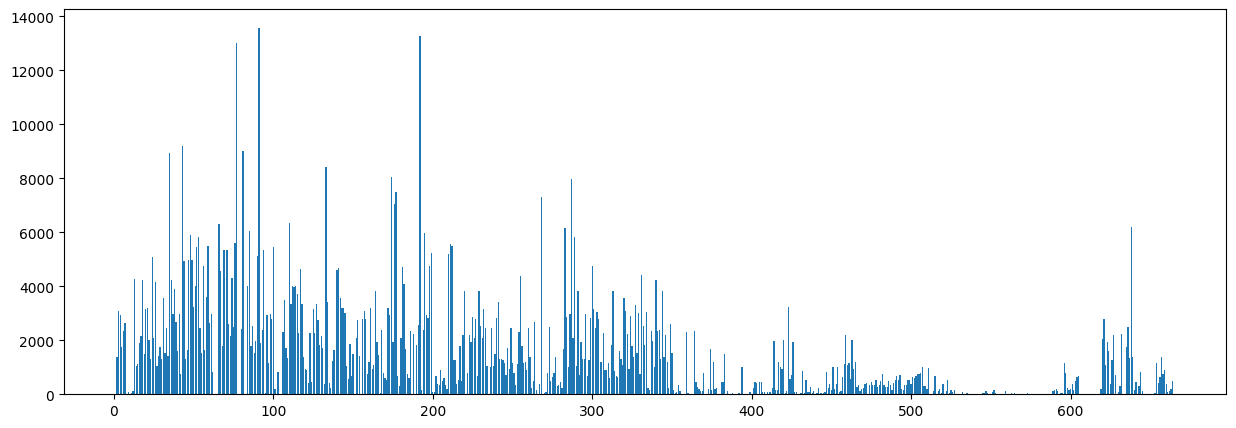

In [217]:
plt.figure(figsize=(15, 5))
test_df = cnt_per_station_df.groupby(by='02 - Rental End Station ID')['01 - Rental Details Rental ID'].count().reset_index()
plt.bar(test_df['02 - Rental End Station ID'], test_df['01 - Rental Details Rental ID'])

In [218]:
df.describe

<bound method NDFrame.describe of          01 - Rental Details Rental ID 01 - Rental Details Local Start Time  \
0                             22178529                  2019-04-01 00:02:22   
1                             22178530                  2019-04-01 00:03:02   
2                             22178531                  2019-04-01 00:11:07   
3                             22178532                  2019-04-01 00:13:01   
4                             22178533                  2019-04-01 00:19:26   
...                                ...                                  ...   
1108156                       23479381                  2019-06-30 23:57:54   
1108159                       23479384                  2019-06-30 23:58:04   
1108160                       23479385                  2019-06-30 23:58:20   
1108161                       23479386                  2019-06-30 23:58:52   
1108162                       23479387                  2019-06-30 23:59:05   

        01 - Rent

In [219]:
USER_TYPE = df['User Type'].unique()
USER_GENDER = df['Member Gender'].unique()

<BarContainer object of 2 artists>

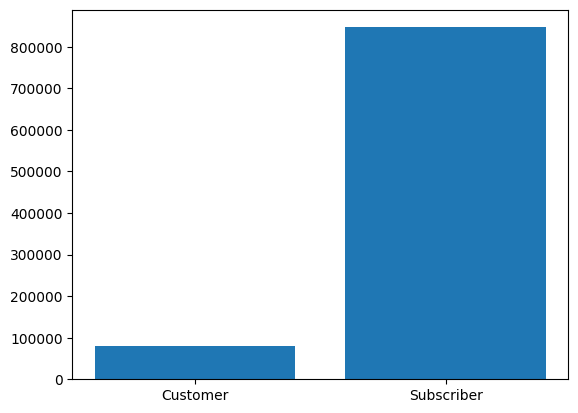

In [220]:
cnt_member_casual_df = df[['01 - Rental Details Rental ID', 'User Type']]
cnt_trips_by_subs = cnt_member_casual_df.groupby(by='User Type').count().reset_index()
plt.bar(cnt_trips_by_subs["User Type"], cnt_trips_by_subs["01 - Rental Details Rental ID"])


55

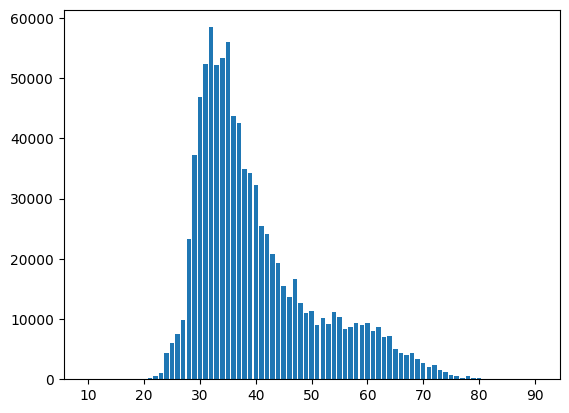

In [221]:
cnt_member_casual_df = df[['01 - Rental Details Rental ID', '05 - Member Details Member Birthday Year']]
cnt_trips_by_age = cnt_member_casual_df.groupby(by='05 - Member Details Member Birthday Year').count().reset_index()
plt.bar(cnt_trips_by_age["05 - Member Details Member Birthday Year"].apply(lambda x: 2024 - int(x)), cnt_trips_by_age["01 - Rental Details Rental ID"])
mean_age = 2024 - int(cnt_trips_by_age["05 - Member Details Member Birthday Year"].mean())
mean_age

<BarContainer object of 2 artists>

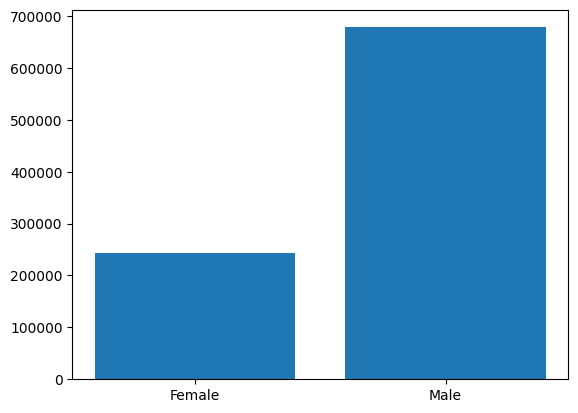

In [222]:
cnt_member_casual_df = df[['01 - Rental Details Rental ID', 'Member Gender']]
cnt_trips_by_gender = cnt_member_casual_df.groupby(by='Member Gender').count().reset_index()
plt.bar(cnt_trips_by_gender["Member Gender"], cnt_trips_by_gender["01 - Rental Details Rental ID"])


In [223]:
timedelta_of_ride_df = df[['01 - Rental Details Local Start Time', '01 - Rental Details Local End Time', 'User Type', "03 - Rental Start Station ID", "Member Gender"]]
timedelta_of_ride_df

,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,User Type,03 - Rental Start Station ID,Member Gender
0,2019-04-01 00:02:22,2019-04-01 00:09:48,Subscriber,81,Male
1,2019-04-01 00:03:02,2019-04-01 00:20:30,Subscriber,317,Female
2,2019-04-01 00:11:07,2019-04-01 00:15:19,Subscriber,283,Male
3,2019-04-01 00:13:01,2019-04-01 00:18:58,Subscriber,26,Male
4,2019-04-01 00:19:26,2019-04-01 00:36:13,Subscriber,202,Male
...,...,...,...,...,...
1108156,2019-06-30 23:57:54,2019-07-01 00:10:47,Subscriber,215,Male
1108159,2019-06-30 23:58:04,2019-07-01 00:14:17,Subscriber,199,Male
1108160,2019-06-30 23:58:20,2019-07-01 00:25:51,Subscriber,319,Female
1108161,2019-06-30 23:58:52,2019-07-01 00:11:24,Subscriber,226,Male


In [224]:
timedelta_of_ride_df[['01 - Rental Details Local Start Time', '01 - Rental Details Local End Time']] = timedelta_of_ride_df[['01 - Rental Details Local Start Time', '01 - Rental Details Local End Time']].apply(pd.to_datetime)


/var/folders/sy/6wglccz17tj4bvcb48c00xsw0000gn/T/ipykernel_4141/1907870807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timedelta_of_ride_df[['01 - Rental Details Local Start Time', '01 - Rental Details Local End Time']] = timedelta_of_ride_df[['01 - Rental Details Local Start Time', '01 - Rental Details Local End Time']].apply(pd.to_datetime)


In [225]:
timedelta_of_ride_df

,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,User Type,03 - Rental Start Station ID,Member Gender
0,2019-04-01 00:02:22,2019-04-01 00:09:48,Subscriber,81,Male
1,2019-04-01 00:03:02,2019-04-01 00:20:30,Subscriber,317,Female
2,2019-04-01 00:11:07,2019-04-01 00:15:19,Subscriber,283,Male
3,2019-04-01 00:13:01,2019-04-01 00:18:58,Subscriber,26,Male
4,2019-04-01 00:19:26,2019-04-01 00:36:13,Subscriber,202,Male
...,...,...,...,...,...
1108156,2019-06-30 23:57:54,2019-07-01 00:10:47,Subscriber,215,Male
1108159,2019-06-30 23:58:04,2019-07-01 00:14:17,Subscriber,199,Male
1108160,2019-06-30 23:58:20,2019-07-01 00:25:51,Subscriber,319,Female
1108161,2019-06-30 23:58:52,2019-07-01 00:11:24,Subscriber,226,Male


In [226]:
timedelta_of_ride_df.dtypes

01 - Rental Details Local Start Time    datetime64[ns]
01 - Rental Details Local End Time      datetime64[ns]
User Type                                       object
03 - Rental Start Station ID                     int64
Member Gender                                   object
dtype: object

In [227]:
timedelta_of_ride_df = timedelta_of_ride_df.assign(timedelta = timedelta_of_ride_df['01 - Rental Details Local End Time'] - timedelta_of_ride_df['01 - Rental Details Local Start Time'])
timedelta_of_ride_df

,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,User Type,03 - Rental Start Station ID,Member Gender,timedelta
0,2019-04-01 00:02:22,2019-04-01 00:09:48,Subscriber,81,Male,0 days 00:07:26
1,2019-04-01 00:03:02,2019-04-01 00:20:30,Subscriber,317,Female,0 days 00:17:28
2,2019-04-01 00:11:07,2019-04-01 00:15:19,Subscriber,283,Male,0 days 00:04:12
3,2019-04-01 00:13:01,2019-04-01 00:18:58,Subscriber,26,Male,0 days 00:05:57
4,2019-04-01 00:19:26,2019-04-01 00:36:13,Subscriber,202,Male,0 days 00:16:47
...,...,...,...,...,...,...
1108156,2019-06-30 23:57:54,2019-07-01 00:10:47,Subscriber,215,Male,0 days 00:12:53
1108159,2019-06-30 23:58:04,2019-07-01 00:14:17,Subscriber,199,Male,0 days 00:16:13
1108160,2019-06-30 23:58:20,2019-07-01 00:25:51,Subscriber,319,Female,0 days 00:27:31
1108161,2019-06-30 23:58:52,2019-07-01 00:11:24,Subscriber,226,Male,0 days 00:12:32


In [228]:
timedelta_of_ride_df.dtypes

01 - Rental Details Local Start Time     datetime64[ns]
01 - Rental Details Local End Time       datetime64[ns]
User Type                                        object
03 - Rental Start Station ID                      int64
Member Gender                                    object
timedelta                               timedelta64[ns]
dtype: object

In [229]:
timedelta_of_ride_df.groupby(by='User Type').apply(lambda x: x.sort_values('timedelta'))

/var/folders/sy/6wglccz17tj4bvcb48c00xsw0000gn/T/ipykernel_4141/1118823776.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  timedelta_of_ride_df.groupby(by='User Type').apply(lambda x: x.sort_values('timedelta'))


01 - Rental Details Local Start Time  \
User Type                                                
Customer   617863                  2019-05-31 09:56:52   
           37544                   2019-04-05 18:34:10   
           266857                  2019-05-01 09:09:45   
           215439                  2019-04-24 16:31:04   
           843038                  2019-06-14 13:47:54   
...                                                ...   
Subscriber 16999                   2019-04-03 07:20:35   
           674724                  2019-06-03 20:34:33   
           350708                  2019-05-09 10:06:47   
           607901                  2019-05-30 17:34:10   
           156255                  2019-04-19 08:27:02   

                  01 - Rental Details Local End Time   User Type  \
User Type                                                          
Customer   617863                2019-05-31 09:57:53    Customer   
           37544                 2019-04-05 18:35:11    Customer   
           266857                2019-05-01 09:10:46    Customer   
           215439                2019-04-24 16:32:05    Customer   
           843038                2019-06-14 13:48:55    Customer   
...                                              ...         ...   
Subscriber 16999                 2019-04-17 18:45:15  Subscriber   
           674724                2019-06-27 01:01:37  Subscriber   
           350708                2019-06-02 12:48:50  Subscriber   
           607901                2019-06-28 10:17:50  Subscriber   
           156255                2019-06-09 17:40:11  Subscriber   

                   03 - Rental Start Station ID Member Gender        timedelta  
User Type                                                                       
Customer   617863                           307          Male  0 days 00:01:01  
           37544                            420          Male  0 days 00:01:01  
           266857                            76          Male  0 days 00:01:01  
           215439                           597           NaN  0 days 00:01:01  
           843038                             6          Male  0 days 00:01:01  
...                                         ...           ...              ...  
Subscriber 16999                            158          Male 14 days 11:24:40  
           674724                           438          Male 23 days 04:27:04  
           350708                           412        Female 24 days 02:42:03  
           607901                           562        Female 28 days 16:43:40  
           156255                            18          Male 51 days 09:13:09  

[926978 rows x 6 columns]

In [230]:
# с ограничением по времени(дельты) от 1 мин до 60 мин
timedelta_of_ride_df = timedelta_of_ride_df[timedelta_of_ride_df['timedelta'] >= datetime.timedelta(minutes=1)]
timedelta_of_ride_df = timedelta_of_ride_df[timedelta_of_ride_df['timedelta'] <= datetime.timedelta(minutes=60)]

In [231]:
# только положительные значения дельты
timedelta_of_ride_df = timedelta_of_ride_df[timedelta_of_ride_df['timedelta'] >= datetime.timedelta()]
timedelta_of_ride_df

,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,User Type,03 - Rental Start Station ID,Member Gender,timedelta
0,2019-04-01 00:02:22,2019-04-01 00:09:48,Subscriber,81,Male,0 days 00:07:26
1,2019-04-01 00:03:02,2019-04-01 00:20:30,Subscriber,317,Female,0 days 00:17:28
2,2019-04-01 00:11:07,2019-04-01 00:15:19,Subscriber,283,Male,0 days 00:04:12
3,2019-04-01 00:13:01,2019-04-01 00:18:58,Subscriber,26,Male,0 days 00:05:57
4,2019-04-01 00:19:26,2019-04-01 00:36:13,Subscriber,202,Male,0 days 00:16:47
...,...,...,...,...,...,...
1108156,2019-06-30 23:57:54,2019-07-01 00:10:47,Subscriber,215,Male,0 days 00:12:53
1108159,2019-06-30 23:58:04,2019-07-01 00:14:17,Subscriber,199,Male,0 days 00:16:13
1108160,2019-06-30 23:58:20,2019-07-01 00:25:51,Subscriber,319,Female,0 days 00:27:31
1108161,2019-06-30 23:58:52,2019-07-01 00:11:24,Subscriber,226,Male,0 days 00:12:32


In [232]:
timedelta_of_ride_df.groupby(by='User Type').apply(lambda x: x.sort_values('timedelta'))

/var/folders/sy/6wglccz17tj4bvcb48c00xsw0000gn/T/ipykernel_4141/1118823776.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  timedelta_of_ride_df.groupby(by='User Type').apply(lambda x: x.sort_values('timedelta'))


01 - Rental Details Local Start Time  \
User Type                                                 
Customer   1029247                  2019-06-26 17:26:56   
           266857                   2019-05-01 09:09:45   
           846843                   2019-06-14 16:23:34   
           37544                    2019-04-05 18:34:10   
           843038                   2019-06-14 13:47:54   
...                                                 ...   
Subscriber 1108149                  2019-06-30 23:53:59   
           747996                   2019-06-08 11:32:07   
           541270                   2019-05-25 13:32:54   
           982632                   2019-06-24 08:20:47   
           796353                   2019-06-11 13:05:28   

                   01 - Rental Details Local End Time   User Type  \
User Type                                                           
Customer   1029247                2019-06-26 17:27:57    Customer   
           266857                 2019-05-01 09:10:46    Customer   
           846843                 2019-06-14 16:24:35    Customer   
           37544                  2019-04-05 18:35:11    Customer   
           843038                 2019-06-14 13:48:55    Customer   
...                                               ...         ...   
Subscriber 1108149                2019-07-01 00:53:58  Subscriber   
           747996                 2019-06-08 12:32:07  Subscriber   
           541270                 2019-05-25 14:32:54  Subscriber   
           982632                 2019-06-24 09:20:47  Subscriber   
           796353                 2019-06-11 14:05:28  Subscriber   

                    03 - Rental Start Station ID Member Gender       timedelta  
User Type                                                                       
Customer   1029247                            90          Male 0 days 00:01:01  
           266857                             76          Male 0 days 00:01:01  
           846843                            199          Male 0 days 00:01:01  
           37544                             420          Male 0 days 00:01:01  
           843038                              6          Male 0 days 00:01:01  
...                                          ...           ...             ...  
Subscriber 1108149                           268          Male 0 days 00:59:59  
           747996                            144          Male 0 days 01:00:00  
           541270                              4          Male 0 days 01:00:00  
           982632                             77          Male 0 days 01:00:00  
           796353                             17          Male 0 days 01:00:00  

[910211 rows x 6 columns]

In [233]:
timedelta_of_ride_df.groupby(by='User Type')['timedelta'].mean()


User Type
Customer     0 days 00:23:49.911612015
Subscriber   0 days 00:12:39.332097080
Name: timedelta, dtype: timedelta64[ns]

In [234]:
timedelta_of_ride_df.describe

<bound method NDFrame.describe of         01 - Rental Details Local Start Time  \
0                        2019-04-01 00:02:22   
1                        2019-04-01 00:03:02   
2                        2019-04-01 00:11:07   
3                        2019-04-01 00:13:01   
4                        2019-04-01 00:19:26   
...                                      ...   
1108156                  2019-06-30 23:57:54   
1108159                  2019-06-30 23:58:04   
1108160                  2019-06-30 23:58:20   
1108161                  2019-06-30 23:58:52   
1108162                  2019-06-30 23:59:05   

        01 - Rental Details Local End Time   User Type  \
0                      2019-04-01 00:09:48  Subscriber   
1                      2019-04-01 00:20:30  Subscriber   
2                      2019-04-01 00:15:19  Subscriber   
3                      2019-04-01 00:18:58  Subscriber   
4                      2019-04-01 00:36:13  Subscriber   
...                                    ..

In [235]:
timedelta_of_ride_df['start_hour_index'] = timedelta_of_ride_df['01 - Rental Details Local Start Time'].dt.hour
timedelta_of_ride_df['end_hour_index'] = timedelta_of_ride_df['01 - Rental Details Local End Time'].dt.hour
timedelta_of_ride_df
mean_timedelta_by_User_Type = timedelta_of_ride_df.groupby(by="User Type")["timedelta"].mean()
mean_timedelta_by_User_Type

User Type
Customer     0 days 00:23:49.911612015
Subscriber   0 days 00:12:39.332097080
Name: timedelta, dtype: timedelta64[ns]

In [236]:
cnt_per_start_hour_df = timedelta_of_ride_df.groupby(by='start_hour_index')['User Type'].count().reset_index()
cnt_per_start_hour_df

,start_hour_index,User Type
0,0,4773
1,1,2655
2,2,1512
3,3,1071
4,4,1670
5,5,8972
6,6,28268
7,7,63579
8,8,81860
9,9,40554


([<matplotlib.axis.XTick at 0x1638b93d0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

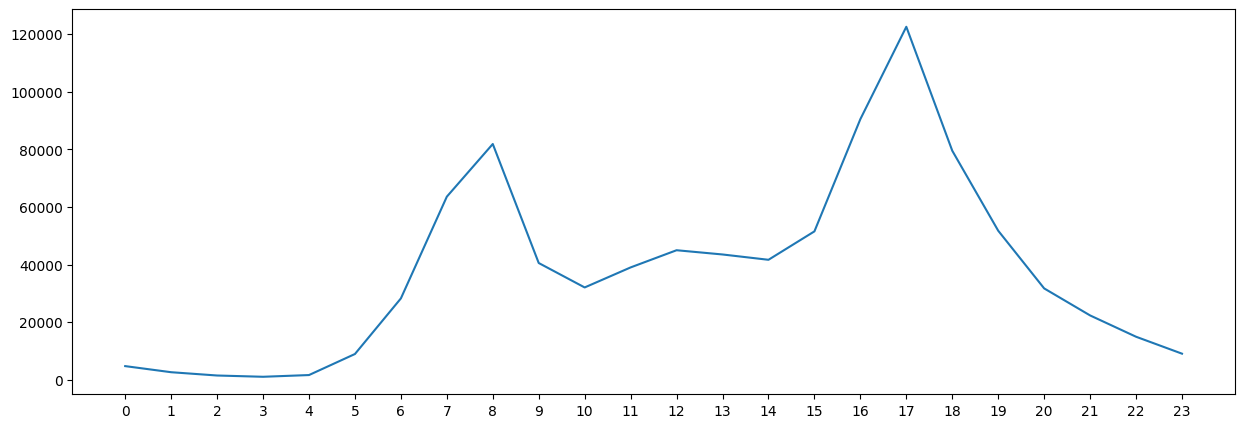

In [237]:
plt.figure(figsize=(15, 5))
plt.plot(cnt_per_start_hour_df['start_hour_index'], cnt_per_start_hour_df['User Type'])
plt.xticks(list(range(24)))

([<matplotlib.axis.XTick at 0x162a57aa0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

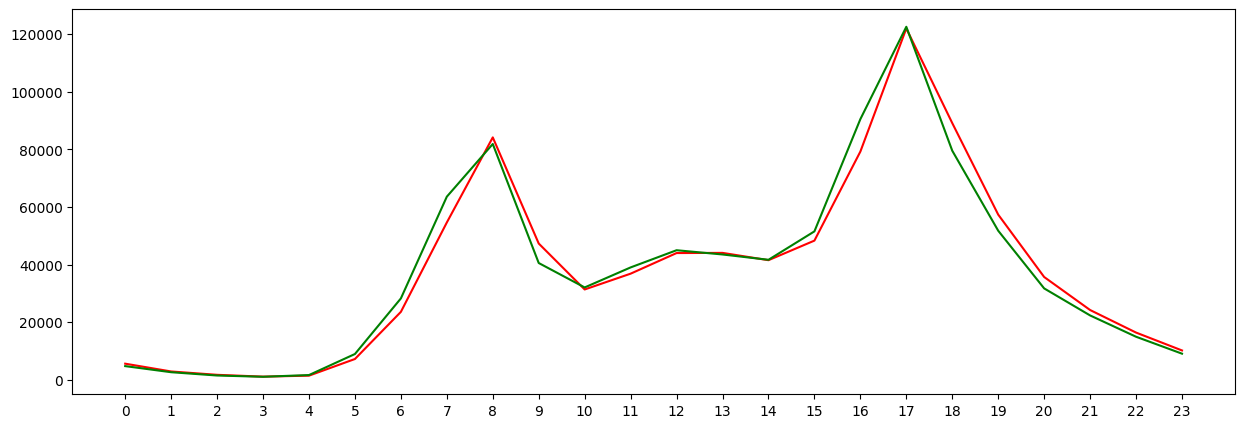

In [238]:
cnt_per_end_hour_df = timedelta_of_ride_df.groupby(by='end_hour_index')['User Type'].count().reset_index()
plt.figure(figsize=(15, 5))
plt.plot(cnt_per_end_hour_df['end_hour_index'], cnt_per_end_hour_df['User Type'], color='r')

plt.plot(cnt_per_start_hour_df['start_hour_index'], cnt_per_start_hour_df['User Type'], color='g')
plt.xticks(list(range(24)))

In [239]:

timedelta_of_ride_df

,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,User Type,03 - Rental Start Station ID,Member Gender,timedelta,start_hour_index,end_hour_index
0,2019-04-01 00:02:22,2019-04-01 00:09:48,Subscriber,81,Male,0 days 00:07:26,0,0
1,2019-04-01 00:03:02,2019-04-01 00:20:30,Subscriber,317,Female,0 days 00:17:28,0,0
2,2019-04-01 00:11:07,2019-04-01 00:15:19,Subscriber,283,Male,0 days 00:04:12,0,0
3,2019-04-01 00:13:01,2019-04-01 00:18:58,Subscriber,26,Male,0 days 00:05:57,0,0
4,2019-04-01 00:19:26,2019-04-01 00:36:13,Subscriber,202,Male,0 days 00:16:47,0,0
...,...,...,...,...,...,...,...,...
1108156,2019-06-30 23:57:54,2019-07-01 00:10:47,Subscriber,215,Male,0 days 00:12:53,23,0
1108159,2019-06-30 23:58:04,2019-07-01 00:14:17,Subscriber,199,Male,0 days 00:16:13,23,0
1108160,2019-06-30 23:58:20,2019-07-01 00:25:51,Subscriber,319,Female,0 days 00:27:31,23,0
1108161,2019-06-30 23:58:52,2019-07-01 00:11:24,Subscriber,226,Male,0 days 00:12:32,23,0


In [253]:
cnt_starts_trips_by_User_Type_SUB = timedelta_of_ride_df[timedelta_of_ride_df["User Type"] == "Subscriber"]
cnt_starts_trips_by_User_Type_SUB = cnt_starts_trips_by_User_Type_SUB.groupby(by="start_hour_index")["User Type"].count().reset_index()
cnt_starts_trips_by_User_Type_SUB



,start_hour_index,User Type
0,0,4352
1,1,2365
2,2,1380
3,3,951
4,4,1586
5,5,8737
6,6,27693
7,7,62298
8,8,79783
9,9,38257


In [241]:
cnt_starts_trips_by_User_Type_CUS = timedelta_of_ride_df[timedelta_of_ride_df["User Type"] == "Customer"]
cnt_starts_trips_by_User_Type_CUS = cnt_starts_trips_by_User_Type_CUS.groupby(by="start_hour_index")["User Type"].count().reset_index()
cnt_starts_trips_by_User_Type_CUS

,start_hour_index,User Type
0,0,421
1,1,290
2,2,132
3,3,120
4,4,84
5,5,235
6,6,575
7,7,1281
8,8,2077
9,9,2297


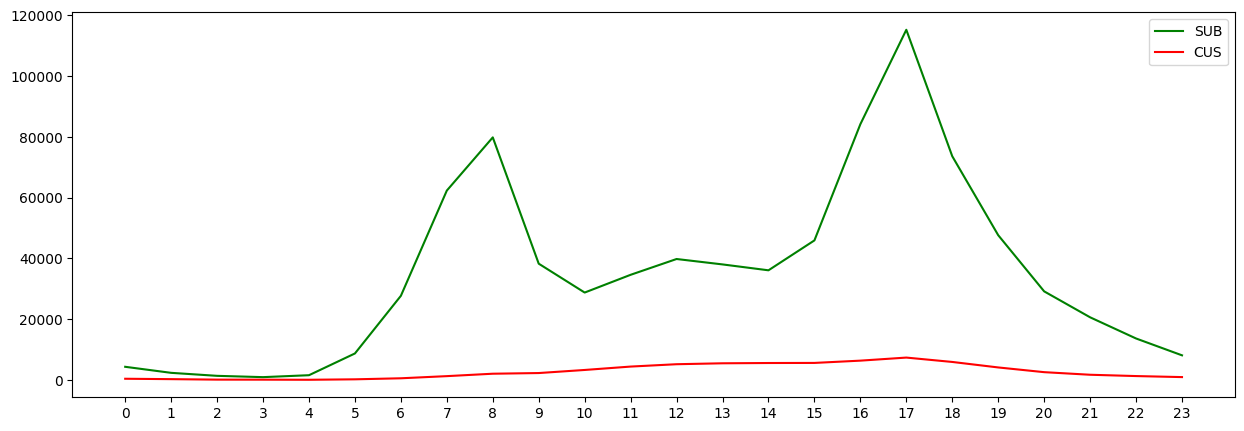

In [242]:
plt.figure(figsize=(15, 5))
plt.plot(cnt_starts_trips_by_User_Type_SUB["start_hour_index"], cnt_starts_trips_by_User_Type_SUB["User Type"], color="g", label="SUB")
plt.plot(cnt_starts_trips_by_User_Type_CUS["start_hour_index"], cnt_starts_trips_by_User_Type_CUS["User Type"], color="r", label="CUS")

plt.xticks(list(range(24)))
plt.legend(loc='upper right')



In [243]:
timedelta_of_ride_df

,01 - Rental Details Local Start Time,01 - Rental Details Local End Time,User Type,03 - Rental Start Station ID,Member Gender,timedelta,start_hour_index,end_hour_index
0,2019-04-01 00:02:22,2019-04-01 00:09:48,Subscriber,81,Male,0 days 00:07:26,0,0
1,2019-04-01 00:03:02,2019-04-01 00:20:30,Subscriber,317,Female,0 days 00:17:28,0,0
2,2019-04-01 00:11:07,2019-04-01 00:15:19,Subscriber,283,Male,0 days 00:04:12,0,0
3,2019-04-01 00:13:01,2019-04-01 00:18:58,Subscriber,26,Male,0 days 00:05:57,0,0
4,2019-04-01 00:19:26,2019-04-01 00:36:13,Subscriber,202,Male,0 days 00:16:47,0,0
...,...,...,...,...,...,...,...,...
1108156,2019-06-30 23:57:54,2019-07-01 00:10:47,Subscriber,215,Male,0 days 00:12:53,23,0
1108159,2019-06-30 23:58:04,2019-07-01 00:14:17,Subscriber,199,Male,0 days 00:16:13,23,0
1108160,2019-06-30 23:58:20,2019-07-01 00:25:51,Subscriber,319,Female,0 days 00:27:31,23,0
1108161,2019-06-30 23:58:52,2019-07-01 00:11:24,Subscriber,226,Male,0 days 00:12:32,23,0


<BarContainer object of 608 artists>

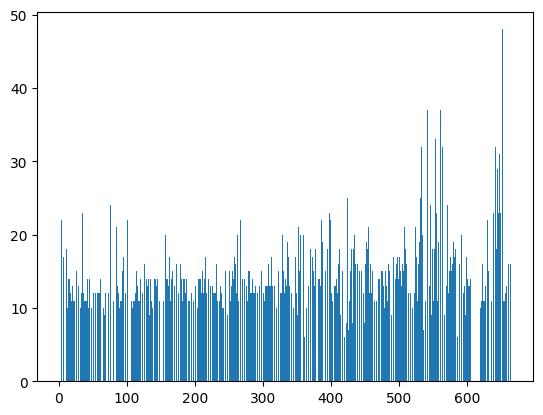

In [251]:
len_trips_by_station_ID = timedelta_of_ride_df.groupby("03 - Rental Start Station ID")["timedelta"].mean()

len_trips_by_station_ID = len_trips_by_station_ID.apply(convert_to_hours).reset_index()

plt.bar(len_trips_by_station_ID["03 - Rental Start Station ID"], len_trips_by_station_ID["timedelta"])

<BarContainer object of 2 artists>

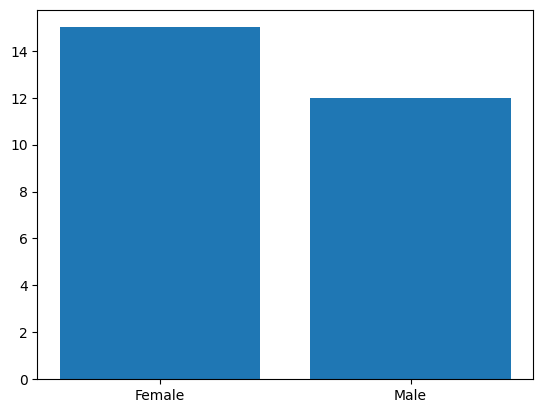

In [252]:
len_trips_by_Gender = timedelta_of_ride_df.groupby("Member Gender")["timedelta"].mean()

len_trips_by_Gender = len_trips_by_Gender.apply(convert_to_hours).reset_index()

plt.bar(len_trips_by_Gender["Member Gender"], len_trips_by_Gender["timedelta"])

In [260]:
len_trips_by_Gender_MALE = timedelta_of_ride_df[timedelta_of_ride_df["Member Gender"] == "Male"]
len_trips_by_Gender_MALE = len_trips_by_Gender_MALE.groupby("03 - Rental Start Station ID")["Member Gender"].count().reset_index()
len_trips_by_Gender_MALE



,03 - Rental Start Station ID,Member Gender
0,2,937
1,3,1884
2,4,2010
3,5,1384
4,6,1419
...,...,...
599,660,214
600,661,57
601,662,50
602,663,121


In [259]:
len_trips_by_Gender_FEMALE = timedelta_of_ride_df[timedelta_of_ride_df["Member Gender"] == "Female"]
len_trips_by_Gender_FEMALE = len_trips_by_Gender_FEMALE.groupby("03 - Rental Start Station ID")["Member Gender"].count().reset_index()
len_trips_by_Gender_FEMALE

,03 - Rental Start Station ID,Member Gender
0,2,586
1,3,1151
2,4,877
3,5,437
4,6,833
...,...,...
581,660,96
582,661,17
583,662,35
584,663,22


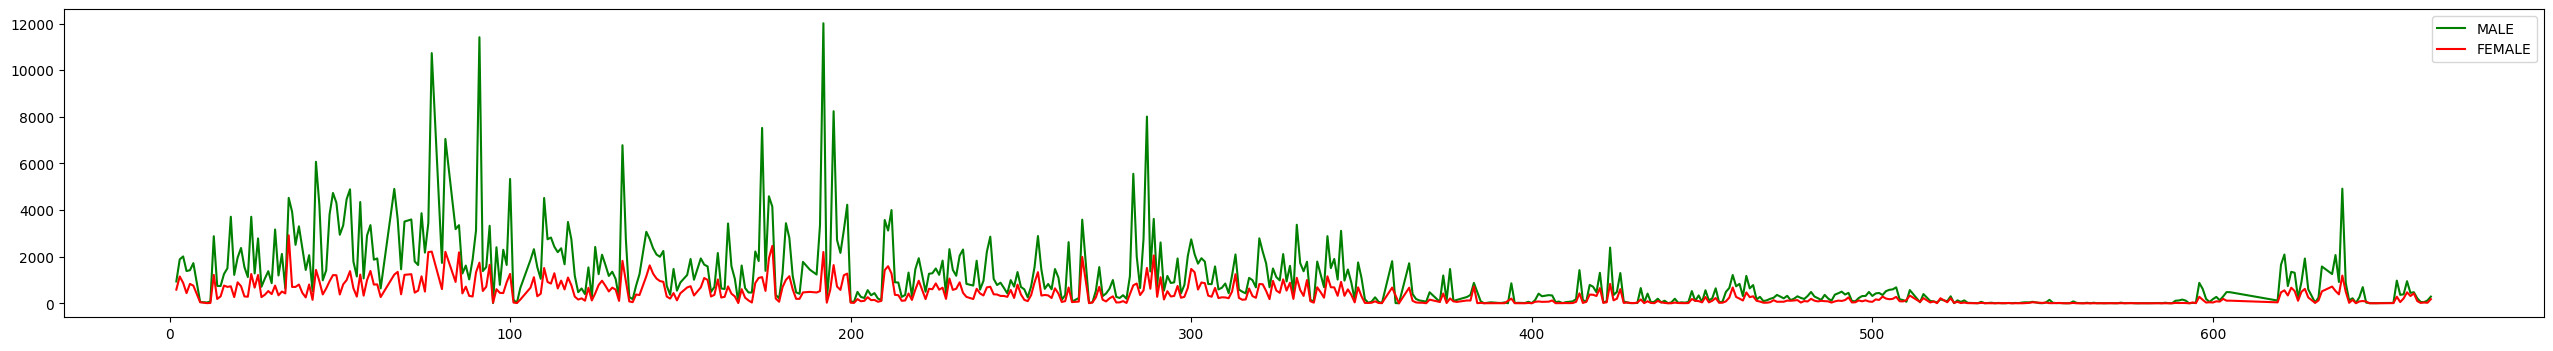

In [310]:
plt.figure(figsize=(32, 4))
plt.plot(len_trips_by_Gender_MALE["03 - Rental Start Station ID"], len_trips_by_Gender_MALE["Member Gender"], color="g", label="MALE")
plt.plot(len_trips_by_Gender_FEMALE["03 - Rental Start Station ID"], len_trips_by_Gender_FEMALE["Member Gender"], color="r", label="FEMALE")
plt.legend(loc="upper right")
